In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle #shuffle the dataset
import pickle #lưu model
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Thuật toán k nearest Neightbor phân loại ML: học có giám sát. Có thể dùng trong cả 2 bài toán Regression và Classification
Tham số quan trọng

K (n_neighbors): số láng giềng.

Nhỏ (1, 2, 3): mô hình nhạy, dễ bị nhiễu (overfitting).

Lớn (10, 15,…): ổn định hơn, nhưng dễ bỏ qua chi tiết (underfitting).

Khoảng cách: thường dùng Euclidean distance (khoảng cách gần nhất theo định lý pythago), ngoài ra có thể dùng Manhattan, Minkowski,...
vd: thường dùng metric ='Mihowski', p=2

Trọng số (weights): có thể chọn đều nhau (uniform) hoặc ưu tiên láng giềng gần hơn (distance).


In [10]:
from sklearn import linear_model, preprocessing

In [36]:
from sklearn.model_selection import train_test_split

In [5]:
data = pd.read_csv(r"C:\Users\ASUS\Downloads\Car_Data_Set_5582ae97ba\Car Data Set\car.data")

In [6]:
data.head(5)

,buying,maint,door,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
le = preprocessing.LabelEncoder() #to convert string to numbers/ mã hóa dữ liệu thành số nguyên dùng cho biến y
# pd.get_dummies chuẩn hóa dữ liệu theo one-hot encoding hệ nhị phân dùng cho biến x
# máy học không học dữ liệu dạng chuỗi

In [19]:
buying = le.fit_transform(list(data["buying"])) #fit_transform chuyển đổi dữ liệu dạng chuỗi sang dạng số nguyên
maint = le.fit_transform(list(data["maint"]))
person = le.fit_transform(list(data["persons"]))
lug_boot = le.fit_transform(list(data["lug_boot"]))
safety = le.fit_transform(list(data["safety"]))



In [27]:
cls= le.fit_transform(list(data["class"]))
door = le.fit_transform(list(data["door"]))

In [ ]:
dt = pd.DataFrame(list(zip(buying, maint, person, lug_boot,safety, cls,door)), columns=['buying', 'maint', 'person', 'lug_boot', 'safety', 'class','door'])

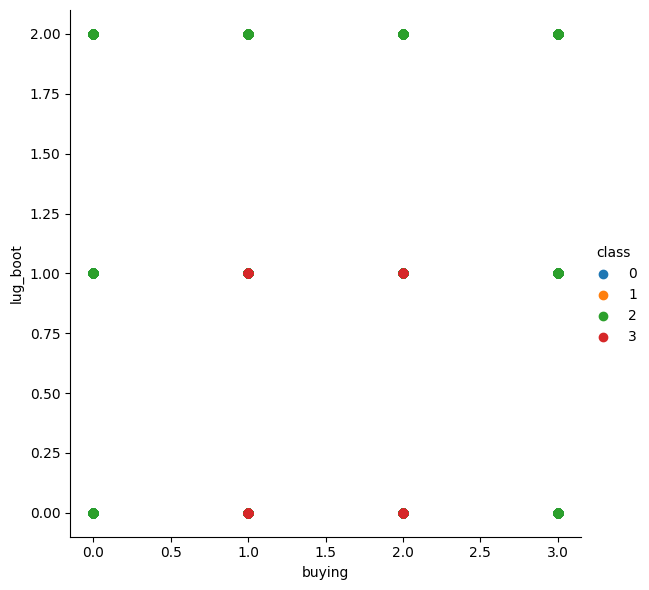

In [82]:
sns.FacetGrid(dt, hue ="class", height =6).map(plt.scatter,"buying","lug_boot").add_legend()

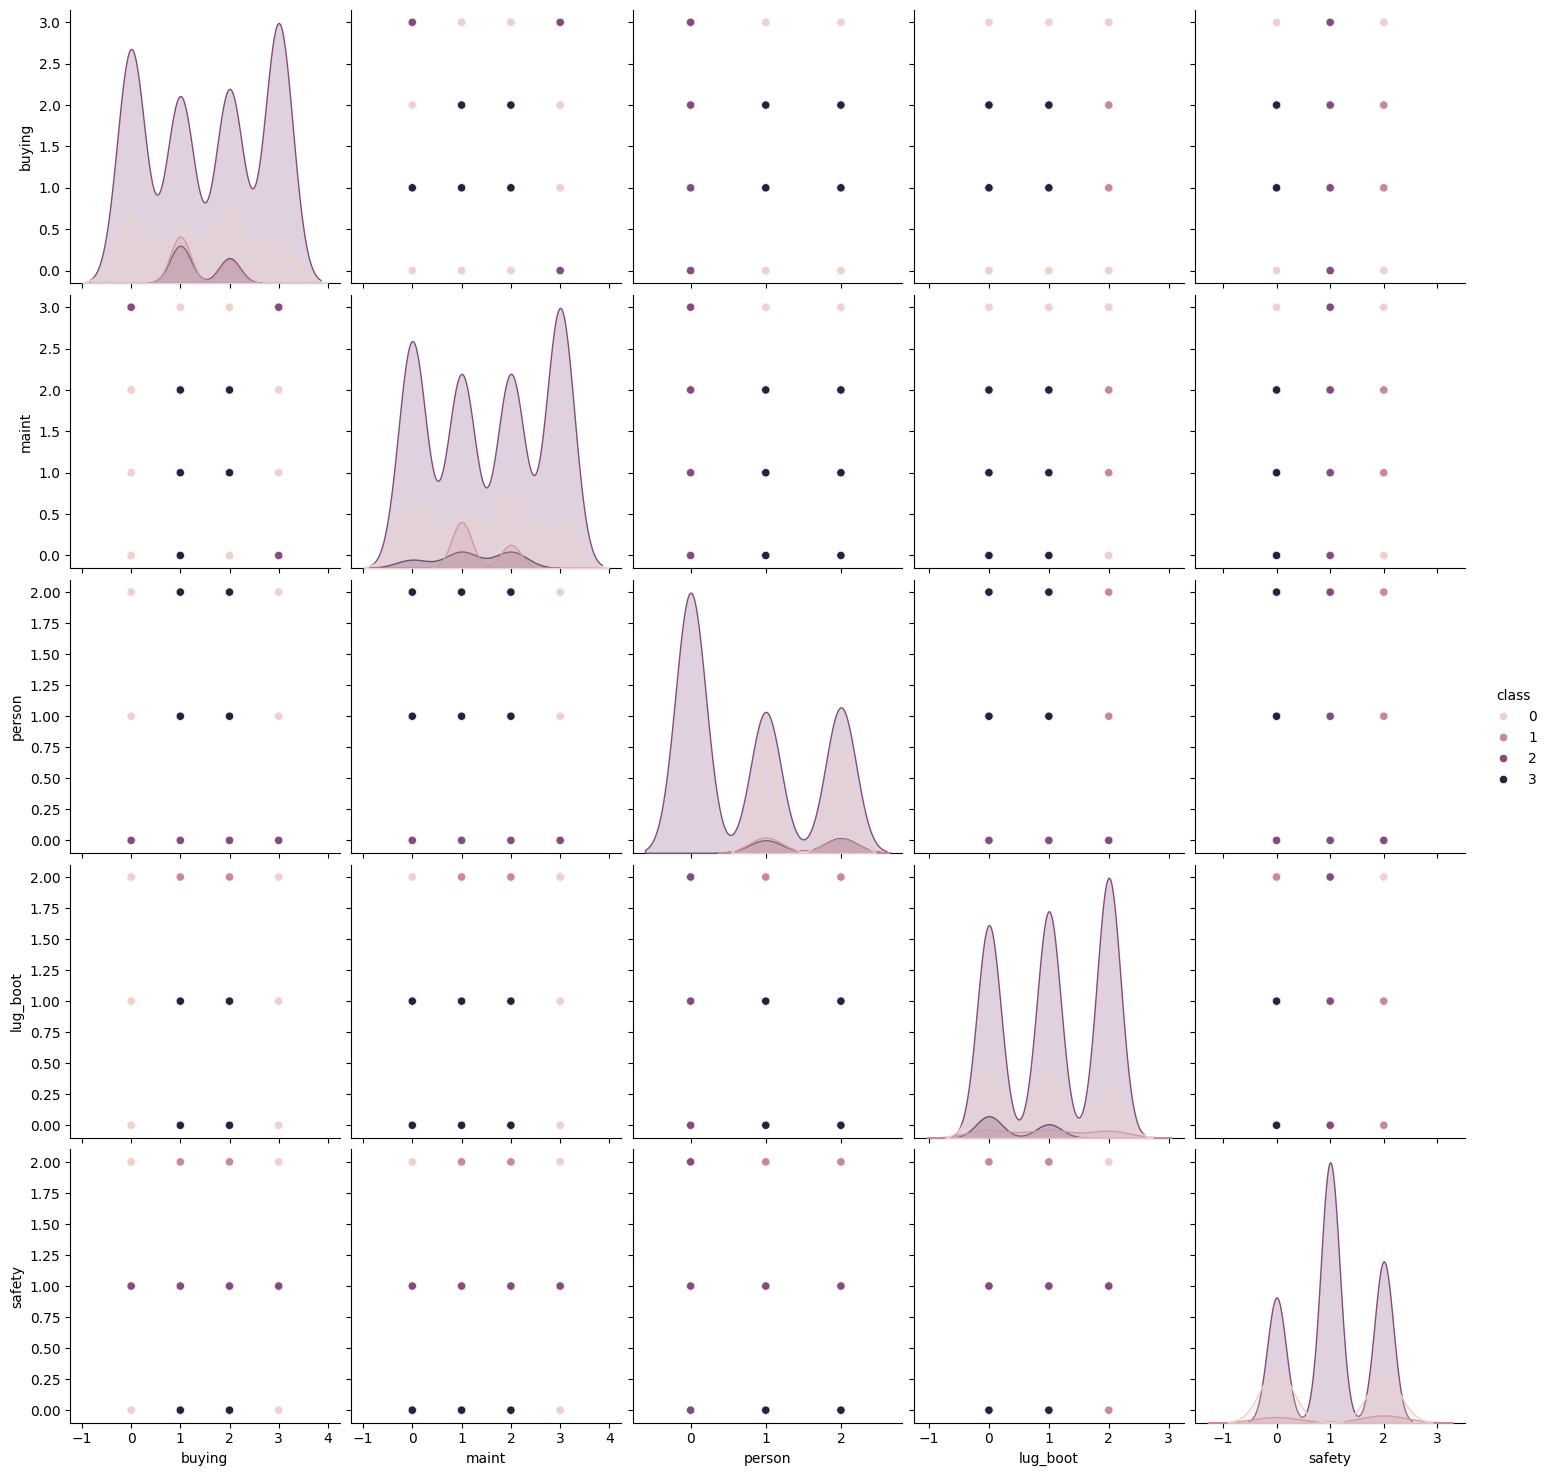

In [83]:
sns.pairplot(dt, hue ="class", height =3)

Các điểm cách khá đều nhau -> uniform

In [2]:
X = list(zip(buying, maint, door, person, lug_boot, safety))
y = list(cls)

NameError: name 'buying' is not defined

In [71]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [1]:
x

NameError: name 'x' is not defined

In [72]:
#Thuât toán KNN (K-Nearest Neighbors)
k_values = range(1,21)
scores =[]
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    acc = model.score(x_test, y_test)
    scores.append(acc)

    
    

In [42]:
score =pd.DataFrame(scores, index=k_values, columns=['accuracy'])

<Axes: ylabel='accuracy'>

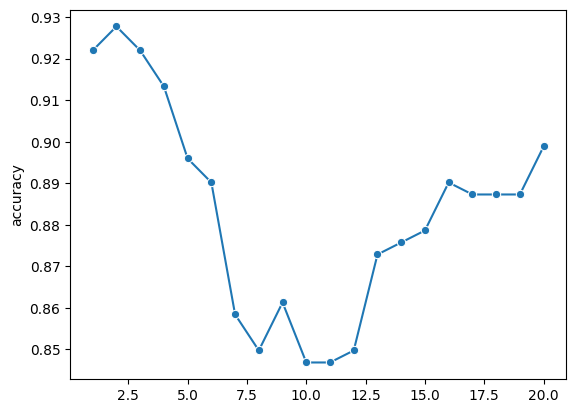

In [ ]:
sns.lineplot(x=k_values,y='accuracy', data=score, marker ='o')

In [45]:
from sklearn.model_selection import  GridSearchCV

In [46]:
# score cao nhất ở k= 1 nên dùng cross vladiation để chọn k tốt nhất
param_grid = {'n_neighbors': range(1,21)}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was pas

,estimator,KNeighborsCla..._neighbors=20)
,param_grid,"{'n_neighbors': range(1, 21)}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,1


In [51]:

grid_search.best_score_

np.float64(0.9283838225291687)

In [52]:
grid_search.best_params_

{'n_neighbors': 1}

In [49]:
best_knn = grid_search.best_estimator_

In [50]:
best_knn.score(x_test, y_test)

0.9219653179190751

Tối ưu nhât là k _neighbor = 1 nhưng vẫn chọn 9 
Số quá nhỏ sẽ dẫn đến underfitting
Số lớn quá sẽ dẫn đến overfitting

In [94]:
Model = KNeighborsClassifier(n_neighbors=9, weights='uniform',metric='minkowski', p=2) 


In [95]:
Model.fit(x_train, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
# Lưu model
with open("knn_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Load lại model
with open("knn_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)


In [96]:
Model.score(x_test, y_test)

0.8728323699421965

In [97]:
predicted = Model.predict(x_test)

In [92]:
names =['không tốt', 'bình thường', 'tốt', 'rất tốt']

The KNN model has a unique method that allows for us to see the neighbors of a given data point. We can use this information to plot our data and get a better idea of where our model may lack accuracy. We can use model.neighbors to do this.

Note: the .neighbors method takes 2D as input, this means if we want to pass one data point we need surround it with [] so that it is in the right shape. Parameters: The parameters for .neighbors are as follows: data(2D array), # of neighbors(int), distance(True or False) Return: This will return to us an array with the index in our data of each neighbor. If distance=True then it will also return the distance to each neighbor from our data point.

In [93]:
for x in range(len(predicted)):
    print("Predicted: ", names[predicted[x]], "Data: ", x_test[x], "Actual: ", names[y_test[x]])
    n = model.kneighbors([x_test[x]], 9, True)
    print("N: ", n)

Predicted:  tốt Data:  (np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(2), np.int64(2)) Actual:  tốt
N:  (array([[1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.41421356, 1.41421356, 1.41421356]]), array([[ 488,  920, 1366,  750,  618,  472, 1218,  803,  990]]))
Predicted:  tốt Data:  (np.int64(3), np.int64(2), np.int64(1), np.int64(1), np.int64(0), np.int64(1)) Actual:  tốt
N:  (array([[1., 1., 1., 1., 1., 1., 1., 1., 1.]]), array([[ 286, 1137,  726,  828,  186,  446,  866,  313,  701]]))
Predicted:  rất tốt Data:  (np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(0)) Actual:  rất tốt
N:  (array([[1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.41421356, 1.41421356, 1.41421356]]), array([[792, 609, 616, 715, 359, 721, 477, 157, 456]]))
Predicted:  tốt Data:  (np.int64(2), np.int64(3), np.int64(1), np.int64(0), np.int64(1), np.int64(1)) Actual:  tốt
N:  (array([[1., 1., 1., 1., 1